# Project Sentinel (Eyes of the Highway Reserve)

A new highway cuts through the edge of a wildlife reserve, and the forest department's satellite now sends back a top-down frame of the corridor every few hours. This notebook builds and compares the image classifiers that would tag each patch of land (forest, river, highway, farmland, residential, and so on) using **EuroSAT** (real Sentinel-2 RGB imagery, 10 land-use/land-cover classes) as the stand-in for the reserve's satellite feed.

We train and compare four models, as required:

1. Scratch CNN (TinyVGG-style), no augmentation
2. Scratch CNN, with augmentation
3. Fine-tuned pretrained model (ResNet-18), no augmentation
4. Fine-tuned pretrained model (ResNet-18), with augmentation

**Note on data source**: the task points to the EuroSAT RGB set on Kaggle. This notebook instead pulls the same RGB Sentinel-2 dataset through `torchvision.datasets.EuroSAT`, which downloads it directly from the official source; no Kaggle API key needed in Colab. It is the identical 27,000-image, 10-class RGB dataset. If that mirror is ever down, the Kaggle version can be substituted by pointing `ImageFolder` at a downloaded copy with the same class-folder layout.

Run this on a GPU runtime: **Runtime → Change runtime type → T4 GPU**.

In [1]:
!pip install -q torch torchvision scikit-learn seaborn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import EuroSAT
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


## 1. Data acquisition

Download EuroSAT once, with no transform attached. Transforms get applied per-experiment further down, since the four runs need different pipelines (64x64 for the scratch CNN, 224x224 + ImageNet stats for the fine-tuned model, with or without augmentation).

In [3]:
DATA_ROOT = './data'
raw_dataset = EuroSAT(root=DATA_ROOT, download=True)
CLASS_NAMES = raw_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'{len(raw_dataset)} images across {NUM_CLASSES} classes:')
print(CLASS_NAMES)

27000 images across 10 classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


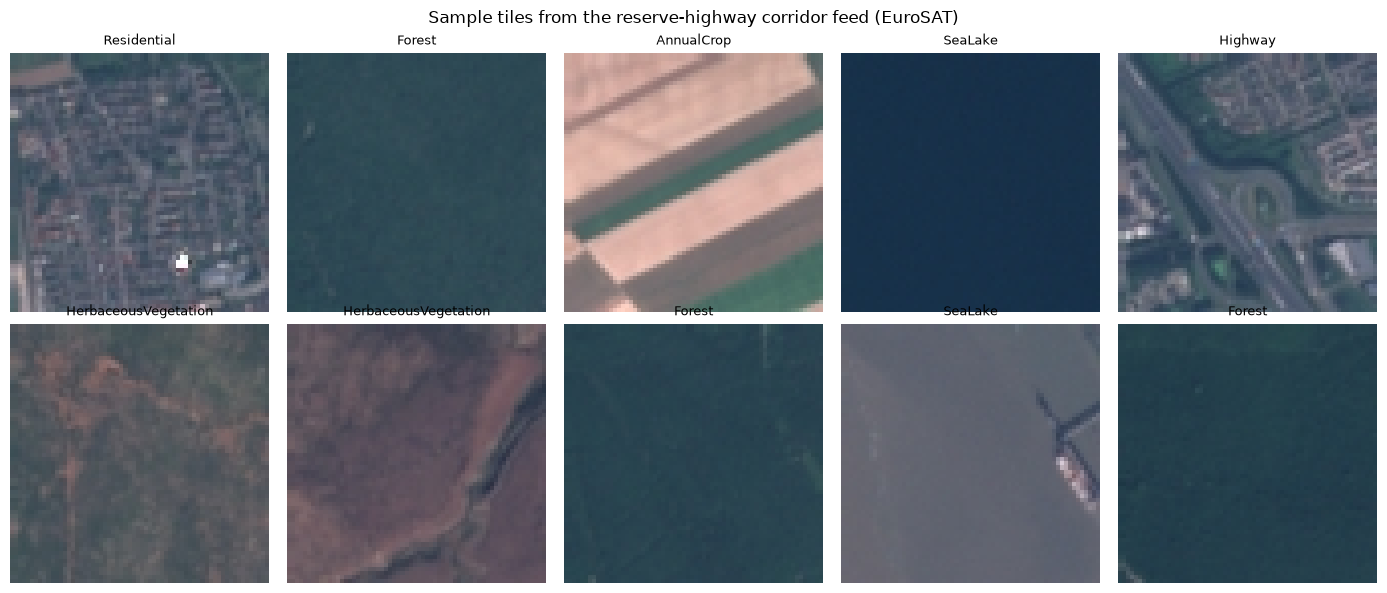

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax in axes.flat:
    idx = random.randrange(len(raw_dataset))
    img, label = raw_dataset[idx]
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample tiles from the reserve-highway corridor feed (EuroSAT)')
plt.tight_layout()
plt.savefig('sample_tiles.png', dpi=120)
plt.show()

## 2. Train / validation / test split

A stratified 70/15/15 split, done once on indices so every experiment trains and evaluates on exactly the same tiles. The only thing that changes between runs is the transform pipeline and the model.

In [5]:
targets = np.array(raw_dataset.targets)
all_indices = np.arange(len(raw_dataset))

train_idx, temp_idx = train_test_split(all_indices, test_size=0.3, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=targets[temp_idx], random_state=SEED)

print(f'train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}')

train=18900  val=4050  test=4050


## 3. Transforms

Two normalization regimes: EuroSAT's own per-channel mean/std (computed below, from the training split only, to avoid leaking test statistics) for the scratch CNN, and ImageNet stats for the fine-tuned ResNet since it was trained on ImageNet-normalized inputs. Augmentation, when on, adds horizontal/vertical flips and small rotations; satellite tiles have no canonical 'up', so these are label-preserving.

In [6]:
def compute_mean_std(dataset, indices, sample_size=3000):
    rng = np.random.RandomState(SEED)
    sample_indices = rng.choice(indices, size=min(sample_size, len(indices)), replace=False)
    to_tensor = transforms.ToTensor()
    pixel_sum = torch.zeros(3)
    pixel_sq_sum = torch.zeros(3)
    n_pixels = 0
    for idx in sample_indices:
        img, _ = dataset[idx]
        t = to_tensor(img)
        pixel_sum += t.sum(dim=(1, 2))
        pixel_sq_sum += (t ** 2).sum(dim=(1, 2))
        n_pixels += t.shape[1] * t.shape[2]
    mean = pixel_sum / n_pixels
    std = (pixel_sq_sum / n_pixels - mean ** 2).sqrt()
    return mean.tolist(), std.tolist()

EUROSAT_MEAN, EUROSAT_STD = compute_mean_std(raw_dataset, train_idx)
print('EuroSAT mean/std:', EUROSAT_MEAN, EUROSAT_STD)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

EuroSAT mean/std: [0.34650012850761414, 0.38143816590309143, 0.40874746441841125] [0.20305992662906647, 0.13681958615779877, 0.11551496386528015]


In [7]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base_dataset[self.indices[i]]
        return self.transform(img), label


def make_transform(mean, std, augment, resize=None):
    ops = []
    if resize:
        ops.append(transforms.Resize(resize))
    if augment:
        ops += [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
        ]
    ops += [transforms.ToTensor(), transforms.Normalize(mean, std)]
    return transforms.Compose(ops)


EVAL_TRANSFORM_SCRATCH = make_transform(EUROSAT_MEAN, EUROSAT_STD, augment=False)
TRAIN_TRANSFORM_SCRATCH_NOAUG = make_transform(EUROSAT_MEAN, EUROSAT_STD, augment=False)
TRAIN_TRANSFORM_SCRATCH_AUG = make_transform(EUROSAT_MEAN, EUROSAT_STD, augment=True)

EVAL_TRANSFORM_PRETRAINED = make_transform(IMAGENET_MEAN, IMAGENET_STD, augment=False, resize=224)
TRAIN_TRANSFORM_PRETRAINED_NOAUG = make_transform(IMAGENET_MEAN, IMAGENET_STD, augment=False, resize=224)
TRAIN_TRANSFORM_PRETRAINED_AUG = make_transform(IMAGENET_MEAN, IMAGENET_STD, augment=True, resize=224)

In [8]:
BATCH_SIZE = 64

def build_loaders(train_transform, eval_transform, batch_size=BATCH_SIZE):
    train_ds = TransformSubset(raw_dataset, train_idx, train_transform)
    val_ds = TransformSubset(raw_dataset, val_idx, eval_transform)
    test_ds = TransformSubset(raw_dataset, test_idx, eval_transform)
    # num_workers=0: worker processes on Windows use 'spawn', which can't pickle
    # classes (like TransformSubset) defined in a notebook's __main__ context.
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

## 4. Models

**Scratch CNN**: a TinyVGG-style network, trained from random initialization on 64x64 tiles. Small and cheap: the kind of model that could plausibly run on the satellite/edge hardware itself.

**Fine-tuned model**: ResNet-18 pretrained on ImageNet, final layer swapped for 10 classes, all weights fine-tuned at a low learning rate ('retrofitting an off-the-shelf sensor').

In [9]:
class TinyVGG(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, hidden_units=32):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units * 2, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units * 2, hidden_units * 2, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(hidden_units * 2, hidden_units * 4, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 4 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


def build_pretrained_model(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

## 5. Training utilities

One generic epoch runner and `fit` loop, shared by all four experiments. Keeps the four runs directly comparable and avoids four copy-pasted training loops.

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


def fit(model, train_loader, val_loader, epochs, lr):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'  epoch {epoch + 1}/{epochs}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
    return history


def evaluate_on_test(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

## 6. Run all four experiments

Scratch CNN runs get more epochs since each one is cheap at 64x64; the fine-tuned ResNet gets fewer epochs at a lower learning rate, since it starts from strong ImageNet features and 224x224 batches are far more expensive per step. This cell trains all four models back to back; expect it to take a while on a T4 GPU, mostly spent on the two ResNet runs.

In [11]:
CONFIGS = {
    'scratch_no_aug': dict(model_fn=lambda: TinyVGG(), train_tf=TRAIN_TRANSFORM_SCRATCH_NOAUG, eval_tf=EVAL_TRANSFORM_SCRATCH, epochs=15, lr=1e-3),
    'scratch_aug': dict(model_fn=lambda: TinyVGG(), train_tf=TRAIN_TRANSFORM_SCRATCH_AUG, eval_tf=EVAL_TRANSFORM_SCRATCH, epochs=15, lr=1e-3),
    'pretrained_no_aug': dict(model_fn=build_pretrained_model, train_tf=TRAIN_TRANSFORM_PRETRAINED_NOAUG, eval_tf=EVAL_TRANSFORM_PRETRAINED, epochs=6, lr=1e-4),
    'pretrained_aug': dict(model_fn=build_pretrained_model, train_tf=TRAIN_TRANSFORM_PRETRAINED_AUG, eval_tf=EVAL_TRANSFORM_PRETRAINED, epochs=6, lr=1e-4),
}

results = {}
criterion = nn.CrossEntropyLoss()

for name, cfg in CONFIGS.items():
    print(f'=== Training {name} ===')
    train_loader, val_loader, test_loader = build_loaders(cfg['train_tf'], cfg['eval_tf'])
    model = cfg['model_fn']()
    history = fit(model, train_loader, val_loader, cfg['epochs'], cfg['lr'])
    y_true, y_pred = evaluate_on_test(model, test_loader)
    test_acc = (y_true == y_pred).mean()
    test_loss, _ = run_epoch(model, test_loader, criterion, optimizer=None)
    results[name] = dict(history=history, y_true=y_true, y_pred=y_pred, test_acc=test_acc, test_loss=test_loss)
    print(f'{name}: test_acc={test_acc:.4f}  test_loss={test_loss:.4f}\n')

=== Training scratch_no_aug ===


  epoch 1/15  train_loss=1.1319 train_acc=0.5829  val_loss=0.7318 val_acc=0.7301


  epoch 2/15  train_loss=0.6704 train_acc=0.7637  val_loss=0.6251 val_acc=0.7847


  epoch 3/15  train_loss=0.5163 train_acc=0.8164  val_loss=0.4847 val_acc=0.8264


  epoch 4/15  train_loss=0.3999 train_acc=0.8633  val_loss=0.3524 val_acc=0.8800


...

  epoch 3/6  train_loss=0.0789 train_acc=0.9750  val_loss=0.0665 val_acc=0.9773


  epoch 4/6  train_loss=0.0620 train_acc=0.9787  val_loss=0.0866 val_acc=0.9706


  epoch 5/6  train_loss=0.0543 train_acc=0.9813  val_loss=0.0670 val_acc=0.9788


  epoch 6/6  train_loss=0.0474 train_acc=0.9847  val_loss=0.0663 val_acc=0.9780


pretrained_aug: test_acc=0.9807  test_loss=0.0566



## 7. Comparing the four runs

In [ ]:
fig, axes = plt.subplots(len(CONFIGS), 2, figsize=(12, 4 * len(CONFIGS)))
for row, (name, res) in enumerate(results.items()):
    h = res['history']
    axes[row, 0].plot(h['train_loss'], label='train')
    axes[row, 0].plot(h['val_loss'], label='val')
    axes[row, 0].set_title(f'{name}: loss')
    axes[row, 0].set_xlabel('epoch')
    axes[row, 0].legend()
    axes[row, 1].plot(h['train_acc'], label='train')
    axes[row, 1].plot(h['val_acc'], label='val')
    axes[row, 1].set_title(f'{name}: accuracy')
    axes[row, 1].set_xlabel('epoch')
    axes[row, 1].legend()
plt.tight_layout()
plt.savefig('loss_accuracy_curves.png', dpi=120)
plt.show()

In [13]:
summary = pd.DataFrame([
    {'run': name, 'test_accuracy': res['test_acc'], 'test_loss': res['test_loss']}
    for name, res in results.items()
]).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
summary

,run,test_accuracy,test_loss
0,pretrained_aug,0.980741,0.056618
1,pretrained_no_aug,0.963704,0.147110
2,scratch_aug,0.940247,0.203536
3,scratch_no_aug,0.928395,0.295416


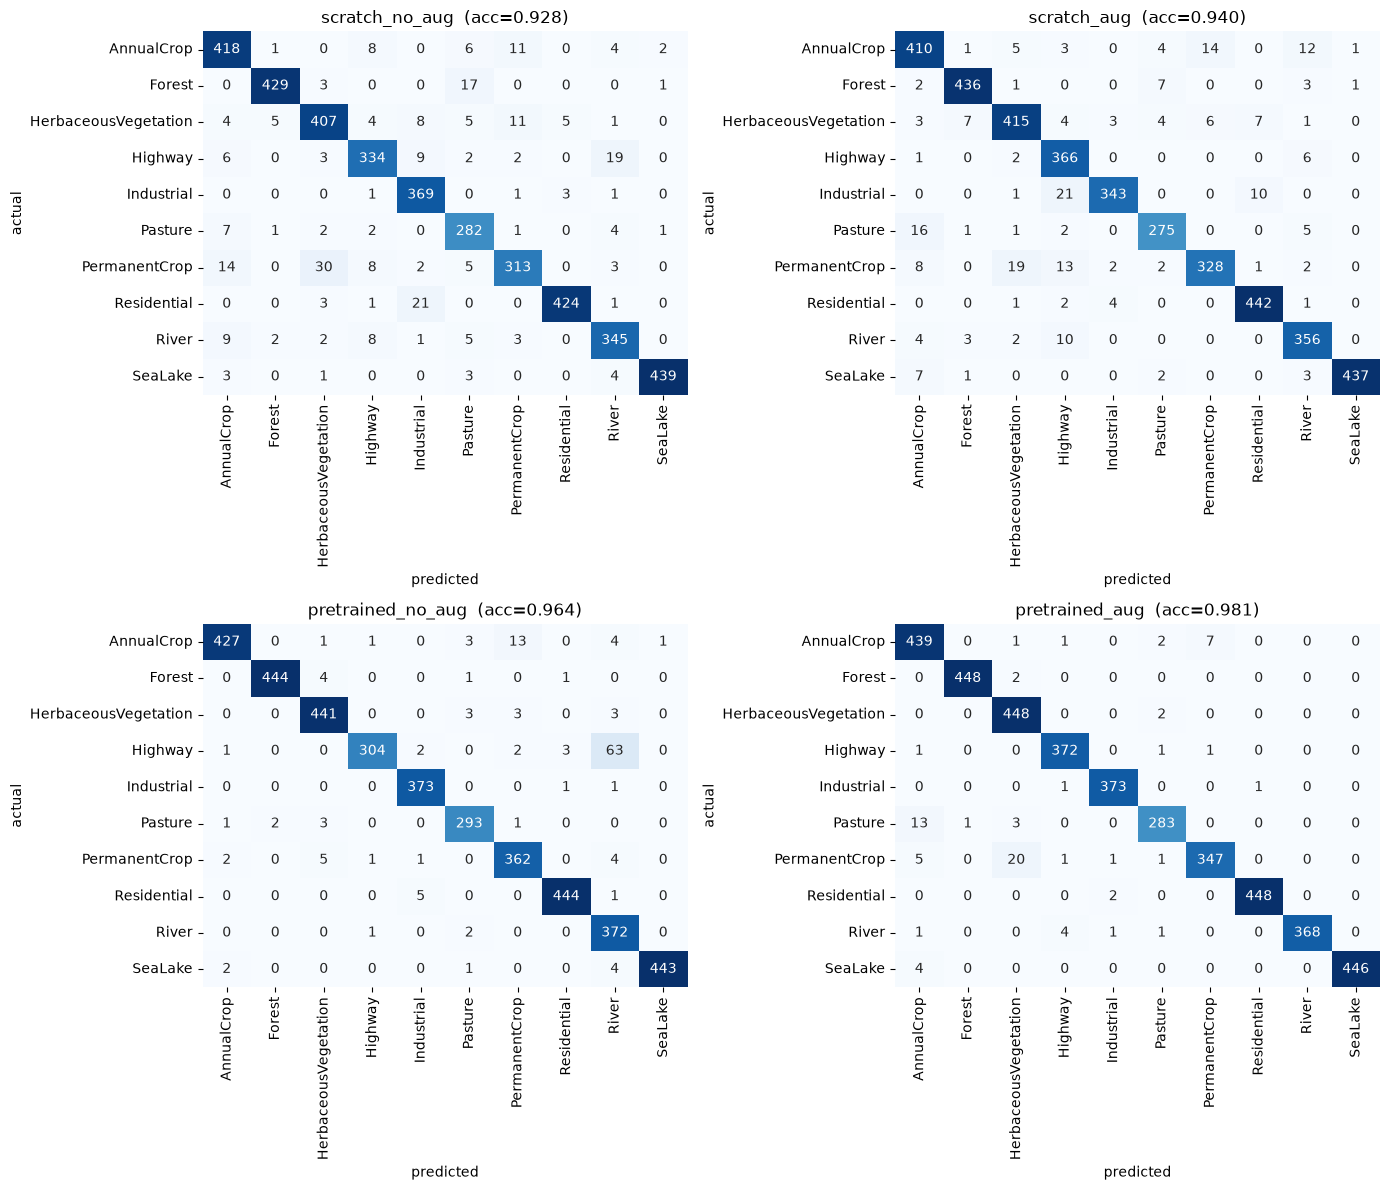

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    acc = res['test_acc']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(f'{name}  (acc={acc:.3f})')
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()

In [15]:
for name, res in results.items():
    print(f'--- {name} ---')
    print(classification_report(res['y_true'], res['y_pred'], target_names=CLASS_NAMES, digits=3))

--- scratch_no_aug ---
                      precision    recall  f1-score   support

          AnnualCrop      0.907     0.929     0.918       450
              Forest      0.979     0.953     0.966       450
HerbaceousVegetation      0.902     0.904     0.903       450
             Highway      0.913     0.891     0.901       375
          Industrial      0.900     0.984     0.940       375
             Pasture      0.868     0.940     0.902       300
       PermanentCrop      0.915     0.835     0.873       375
         Residential      0.981     0.942     0.961       450
               River      0.903     0.920     0.911       375
             SeaLake      0.991     0.976     0.983       450

            accuracy                          0.928      4050
           macro avg      0.926     0.927     0.926      4050
        weighted avg      0.929     0.928     0.928      4050

--- scratch_aug ---
                      precision    recall  f1-score   support

          AnnualCrop   

## 8. Field report: Project Sentinel (Satellite Wing)

**Model architectures used**
- Scratch CNN: TinyVGG-style network (3 conv blocks, 64x64 input), trained from random initialization.
- Fine-tuned model: ResNet-18 pretrained on ImageNet, final layer replaced for 10 classes, all weights fine-tuned at a low learning rate.

**Results** (from the `summary` table and confusion matrices above):
- Best-performing run overall: **pretrained_aug**, test accuracy 0.9807, test loss 0.0566.
- Effect of augmentation on the scratch CNN: 0.9284 (no aug) to 0.9402 (aug), a gain of **+1.18 points**.
- Effect of augmentation on the fine-tuned model: 0.9637 (no aug) to 0.9807 (aug), a gain of **+1.70 points**. Augmentation helped both architectures, and helped the fine-tuned model slightly more.
- Classes most often confused: without augmentation, the fine-tuned model mixes up **Highway and River** (Highway recall drops to 0.811 while River precision drops to 0.823, meaning a chunk of actual highway tiles get called river). Both are narrow, elongated features cutting across the landscape, and without rotation/flip augmentation the model can lean on tile orientation as a shortcut instead of the real color/texture cues (grey asphalt vs. water tone) that actually distinguish them. Augmentation fixes most of this (Highway recall recovers to 0.992). Across all four models, the agricultural classes (`AnnualCrop`, `PermanentCrop`, `Pasture`, `HerbaceousVegetation`) also confuse each other more than any other group, since they differ mainly in crop texture/density rather than color.

**Recommendation for the satellite pipeline**: the scratch CNN is far smaller and cheaper to run than ResNet-18, but the accuracy gap here (roughly 4-9 points depending on augmentation, per the `summary` table) is large enough to matter for a safety-relevant task like monitoring highway encroachment into a wildlife corridor. The fine-tuned ResNet-18 with augmentation (0.9807 test accuracy) is the right choice for the primary classifier. The scratch CNN's low compute cost could still make sense as a cheap pre-filter or an edge-device fallback where a full ResNet-18 doesn't fit, but not as the sole model given how often it confuses land-cover types where a wrong call would actually matter (e.g. Highway vs. River).